In [8]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

In [17]:
hold=df['job_title_short'].value_counts().to_frame()

Text(0, 0.5, '')

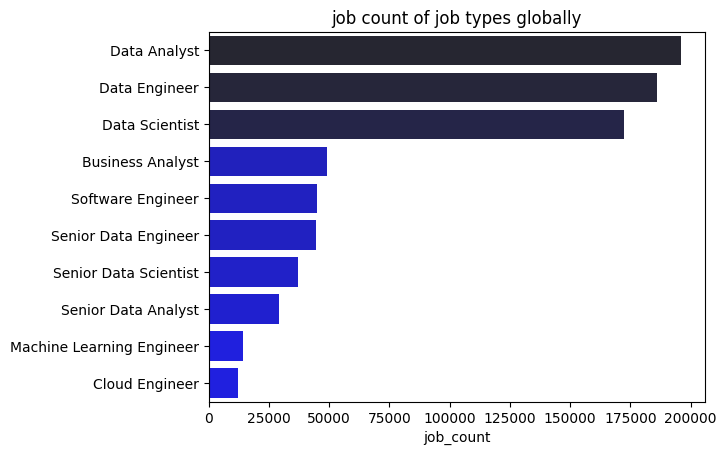

In [30]:
sns.barplot(data=hold,y='job_title_short',x='count',hue='count',palette='dark:b_r',legend=False)
plt.title("job count of job types globally")
plt.xlabel("job_count")
plt.ylabel("")

In [31]:
df_ds=df[df['job_title_short']=='Data Scientist']

In [36]:
hold=df_ds['job_location'].value_counts().head().to_frame()

Text(0, 0.5, '')

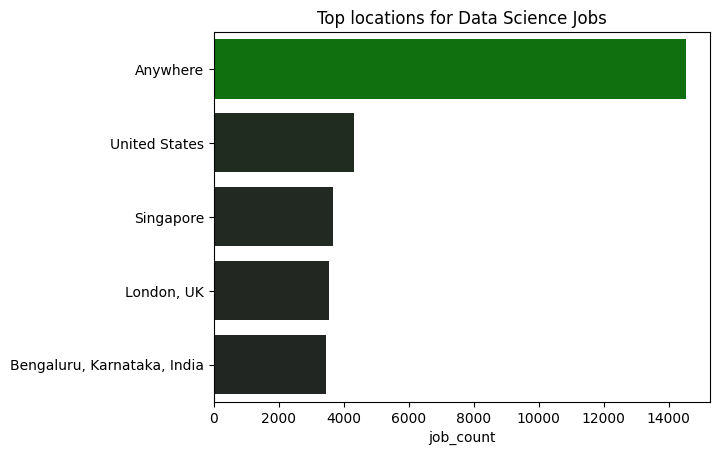

In [49]:
sns.barplot(data=hold,y='job_location',x='count',hue='count',palette='dark:g',legend=False)
plt.title("Top locations for Data Science Jobs")
plt.xlabel("job_count")
plt.ylabel("")

In [51]:
job_req={'job_work_from_home':'job_no_work_from_home',
         'job_no_degree_mention':'job_degree_mention',
         'job_health_insurance':'job_no_health_insurance'
         }

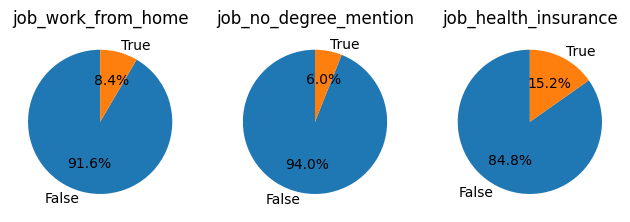

In [65]:
fig,ax=plt.subplots(1,3)
for i,(key,val) in enumerate(job_req.items()): 
    df_ds[key].value_counts().plot(kind='pie',ax=ax[i],autopct='%1.1f%%',startangle=90,title=key)
    plt.tight_layout()
    ax[i].set_ylabel("")

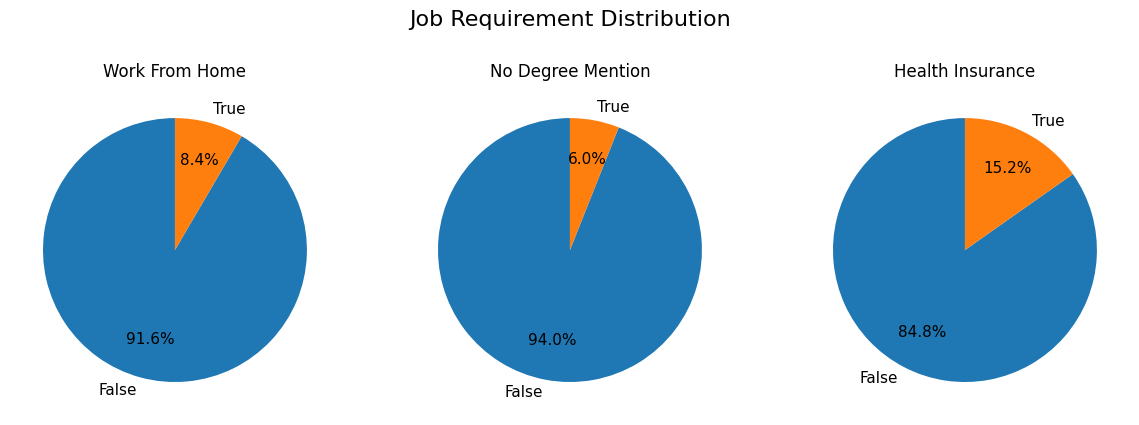

In [63]:
#updated using chatgpt 
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

for i, (key, val) in enumerate(job_req.items()):

    df_ds[key].value_counts().plot(
        kind='pie',
        ax=ax[i],
        autopct='%1.1f%%',
        startangle=90,
        title=key.replace('job_', '').replace('_', ' ').title(),
        ylabel='',
        pctdistance=0.7,
        textprops={'fontsize': 11}
    )

plt.suptitle(
    'Job Requirement Distribution',
    fontsize=16,
    y=1.05
)

plt.tight_layout()
plt.show()

Text(0, 0.5, '')

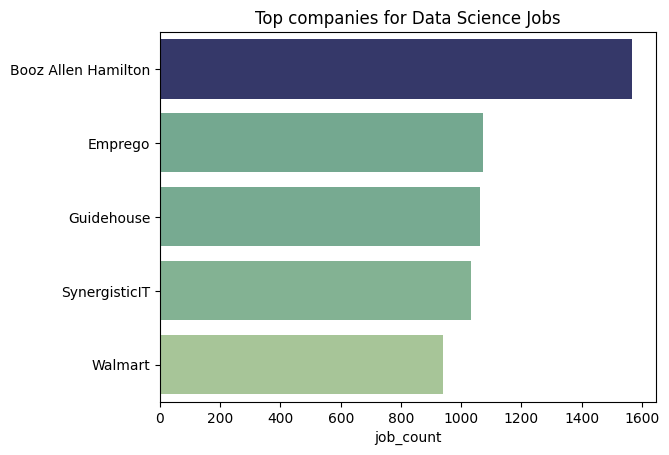

In [81]:
hold=df_ds[['company_name']].value_counts().sort_values(ascending=False).head().to_frame()
sns.barplot(data=hold,y='company_name',x='count',hue='count',palette='crest',legend=False)
plt.title("Top companies for Data Science Jobs")
plt.xlabel("job_count")
plt.ylabel("")